Phase 1: Detectron2

In [ ]:
import sys
import os

# Add the directory containing Response_Integration.py to Python's path
module_path = r"C:\Users\devan\Downloads\Coding\ML Perception"
if module_path not in sys.path:
    sys.path.append(module_path)

# Now run your imports
from Poly_points import get_polypoints, get_extpoints
from Prod_Shape_Model_IOU import check_iou, data_filter
#from Response_Integration import mapping_row_column, remove_extra_char
from stack_handling_prod_clustering import prod_cluster
from Empty_space_addition import driver_code_adding_empty_space

In [3]:
import onnxruntime as rt
from detectron2.structures import BitMasks
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
import torch
import cv2
import numpy as np

#----------our define modules---------- 
from Poly_points import get_polypoints
from Poly_points import get_extpoints
from Prod_Shape_Model_IOU import check_iou, data_filter
#from Response_Integration import mapping_row_column,remove_extra_char
from stack_handling_prod_clustering import prod_cluster
from Empty_space_addition import driver_code_adding_empty_space

In [4]:
def getPredictor(yaml, weights, score = 0.7):
    cfg = get_cfg()
    cfg.merge_from_file(yaml)
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = score
    cfg.MODEL.WEIGHTS = weights
    cfg.MODEL.DEVICE = "cpu"
    predictor = DefaultPredictor(cfg)
    return predictor

In [5]:
global img_data
img_data = cv2.imread('sam3_buckets_batch/002as9ksdxs2a_stitched_buckets.png')
model = getPredictor("uniliver_config.yaml", "uniliver_model_final.pth")
prod_model = getPredictor("premier_config.yaml", "premier_model_final.pth")

c:\Users\devan\Downloads\Coding\ML Perception\.venv\lib\site-packages\torch\functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4217.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0902 17:00:12.654844 1472 Lib\site-packages\torch\fx\_symbolic_trace.py:56] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


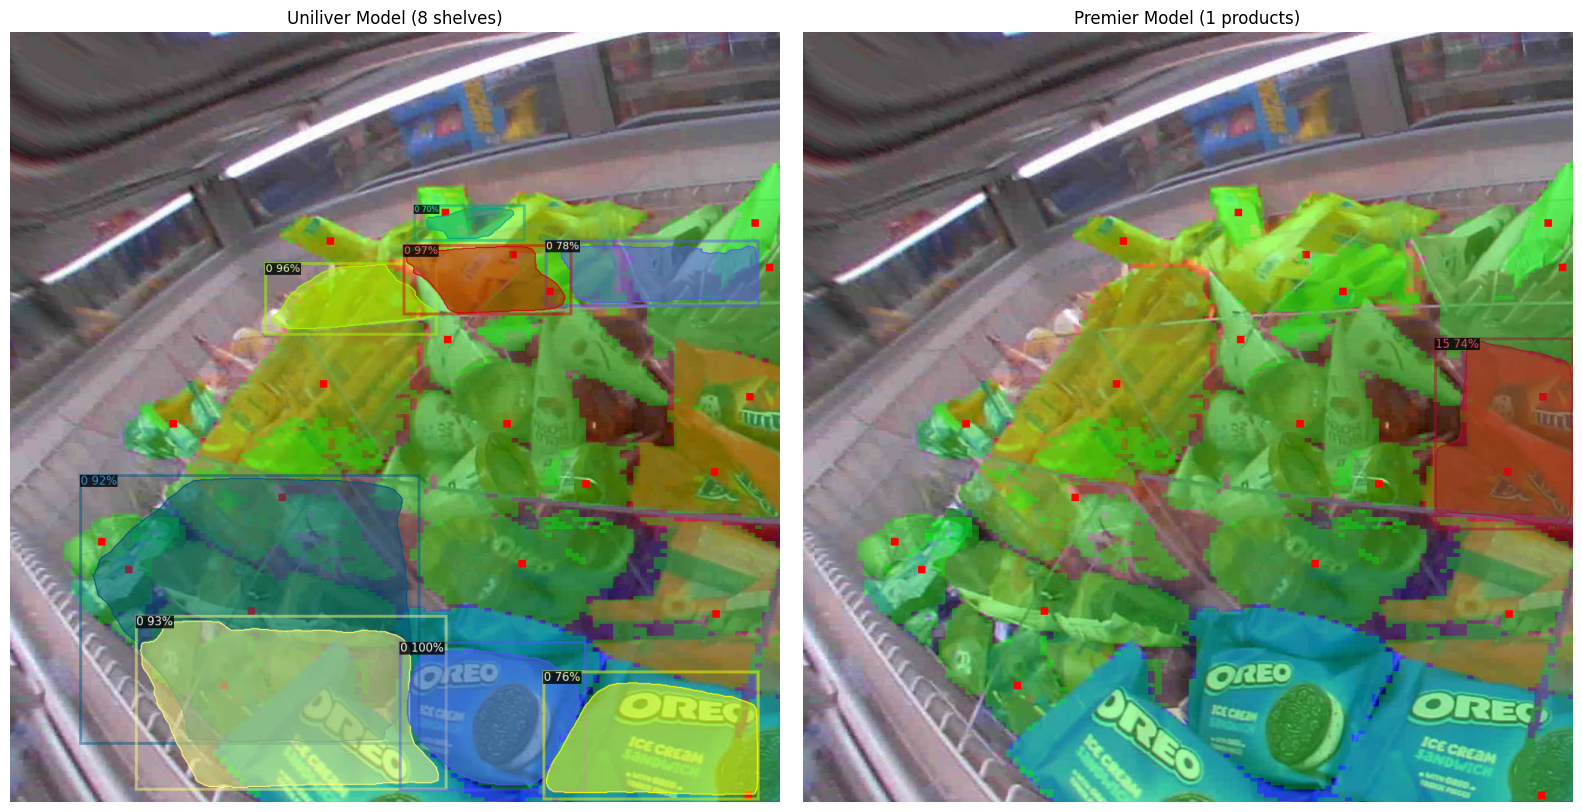

In [6]:
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog

if img_data is not None:
    h, w = img_data.shape[:2]
    crop = img_data[0:min(1024, h), 0:min(1024, w)]
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

    # 1. Uniliver (Shelf / Bucket model)
    out1 = model(crop)
    v1 = Visualizer(crop_rgb, scale=1.0)
    vis_out1 = v1.draw_instance_predictions(out1["instances"].to("cpu"))

    # 2. Premier (Product SKU model)
    out2 = prod_model(crop)
    v2 = Visualizer(crop_rgb, scale=1.0)
    vis_out2 = v2.draw_instance_predictions(out2["instances"].to("cpu"))

    # Plot results side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(vis_out1.get_image())
    axes[0].set_title(f"Uniliver Model ({len(out1['instances'])} shelves)")
    axes[0].axis("off")

    axes[1].imshow(vis_out2.get_image())
    axes[1].set_title(f"Premier Model ({len(out2['instances'])} products)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

In [11]:
import os
import random
import matplotlib.pyplot as plt
import cv2
from detectron2.utils.visualizer import Visualizer

# 1. Create output folder if it doesn't exist
output_dir = "inference_crops_output"
os.makedirs(output_dir, exist_ok=True)

if img_data is not None:
    h, w = img_data.shape[:2]
    crop_h, crop_w = 1024, 1024

    # Calculate safe crop bounds
    max_y = max(0, h - crop_h)
    max_x = max(0, w - crop_w)

    print(f"Running 25 crop evaluations... Saving to '{output_dir}/'")

    for i in range(25):
        # Pick random top-left corner coordinates for each crop
        y_start = random.randint(0, max_y) if max_y > 0 else 0
        x_start = random.randint(0, max_x) if max_x > 0 else 0

        crop = img_data[y_start : y_start + crop_h, x_start : x_start + crop_w]
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

        # 1. Uniliver (Shelf / Bucket model)
        out1 = model(crop)
        v1 = Visualizer(crop_rgb, scale=1.0)
        vis_out1 = v1.draw_instance_predictions(out1["instances"].to("cpu"))

        # 2. Premier (Product SKU model)
        out2 = prod_model(crop)
        v2 = Visualizer(crop_rgb, scale=1.0)
        vis_out2 = v2.draw_instance_predictions(out2["instances"].to("cpu"))

        # Plot side-by-side
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        
        axes[0].imshow(vis_out1.get_image())
        axes[0].set_title(f"Uniliver Model ({len(out1['instances'])} shelves)")
        axes[0].axis("off")

        axes[1].imshow(vis_out2.get_image())
        axes[1].set_title(f"Premier Model ({len(out2['instances'])} products)")
        axes[1].axis("off")

        plt.suptitle(f"Crop {i+1}/25 — Offset: (y={y_start}, x={x_start})", fontsize=14)
        plt.tight_layout()

        # Save plot to file and close figure to clear memory
        save_path = os.path.join(output_dir, f"crop_eval_{i+1:02d}.png")
        plt.savefig(save_path, bbox_inches="tight")
        plt.close(fig)

    print(f"Done! Saved 25 evaluation images to '{output_dir}'.")

Running 25 crop evaluations... Saving to 'inference_crops_output/'
Done! Saved 25 evaluation images to 'inference_crops_output'.


In [12]:
instances = out2["instances"]
print("Num instances:", len(instances))
print("Scores:", instances.scores)
print("Classes:", instances.pred_classes)
print("Boxes:", instances.pred_boxes)

Num instances: 1
Scores: tensor([0.7916])
Classes: tensor([15])
Boxes: Boxes(tensor([[ 493.9195,  551.4855,  987.3509, 1017.7159]]))


cwd: c:\Users\devan\Downloads\Coding\ML Perception
img exists: True
uniliver cfg exists: True
uniliver weights exists: True
premier cfg exists: True
premier weights exists: True
img loaded: True
model loaded: True
prod_model loaded: True


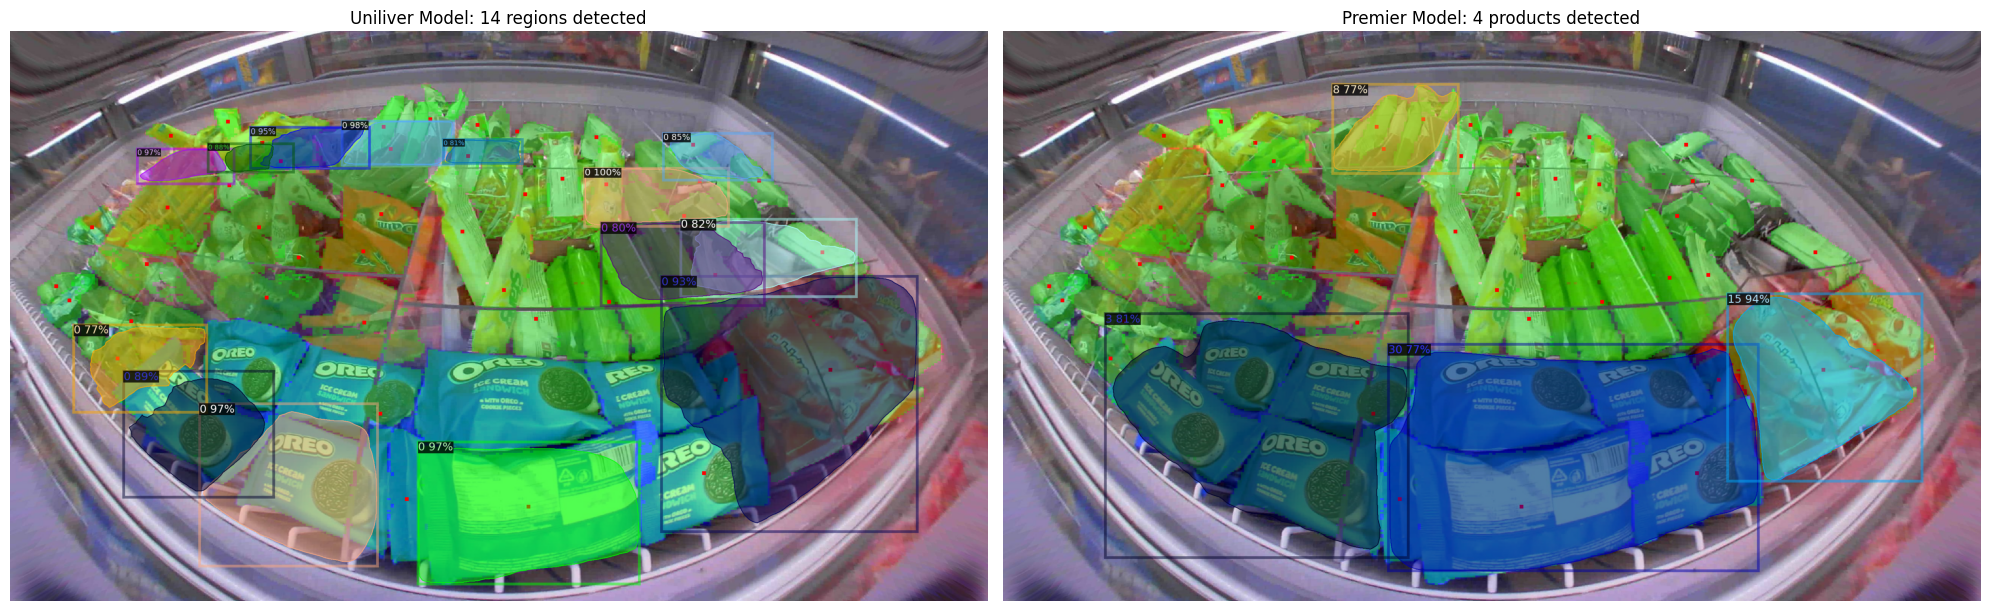

In [13]:
import os
import cv2
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer

# 1. Setup paths
workspace_root = os.getcwd()
img_path = os.path.join(workspace_root, 'sam3_buckets_batch', '002as9ksdxs2a_stitched_buckets.png')

uniliver_cfg = os.path.join(workspace_root, 'uniliver_config.yaml')
uniliver_weights = os.path.join(workspace_root, 'uniliver_model_final.pth')

premier_cfg = os.path.join(workspace_root, 'premier_config.yaml')
premier_weights = os.path.join(workspace_root, 'premier_model_final.pth')

# 2. Check path existence
print('cwd:', workspace_root)
print('img exists:', os.path.exists(img_path))
print('uniliver cfg exists:', os.path.exists(uniliver_cfg))
print('uniliver weights exists:', os.path.exists(uniliver_weights))
print('premier cfg exists:', os.path.exists(premier_cfg))
print('premier weights exists:', os.path.exists(premier_weights))

# 3. Load image & models
global img_data
img_data = cv2.imread(img_path)

model = getPredictor(uniliver_cfg, uniliver_weights)
prod_model = getPredictor(premier_cfg, premier_weights)

print('img loaded:', img_data is not None)
print('model loaded:', model is not None)
print('prod_model loaded:', prod_model is not None)

# 4. Run inference and render side-by-side visualization
if img_data is not None and model is not None and prod_model is not None:
    img_rgb = cv2.cvtColor(img_data, cv2.COLOR_BGR2RGB)

    # Shelf/Bucket inference
    uniliver_outputs = model(img_data)
    v_uniliver = Visualizer(img_rgb, scale=0.8)
    vis_uniliver = v_uniliver.draw_instance_predictions(uniliver_outputs["instances"].to("cpu"))

    # Product SKU inference
    premier_outputs = prod_model(img_data)
    v_premier = Visualizer(img_rgb, scale=0.8)
    vis_premier = v_premier.draw_instance_predictions(premier_outputs["instances"].to("cpu"))

    # Plot results
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    axes[0].imshow(vis_uniliver.get_image())
    axes[0].set_title(f"Uniliver Model: {len(uniliver_outputs['instances'])} regions detected")
    axes[0].axis("off")

    axes[1].imshow(vis_premier.get_image())
    axes[1].set_title(f"Premier Model: {len(premier_outputs['instances'])} products detected")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

In [14]:
def executeModel_masked(model):
        predictor = model

        outputs = predictor(img_data)

        map_data = {0:'1'}

        label = list(map(map_data.get, outputs['instances'].pred_classes.tolist()))
        score = outputs['instances'].scores.tolist()
        b_bbox = outputs['instances'].pred_boxes.tensor.cpu().numpy().astype(int).tolist()

        orig_height = outputs['instances'].image_size[0]
        orig_width = outputs['instances'].image_size[1]

        masks = np.asarray(outputs["instances"].to("cpu").pred_masks)

        mask_data = get_polypoints(orig_height, orig_width,masks)

        mask_cord = get_extpoints(mask_data)

        mask_cord_all = [np.array(i) for i in mask_cord]

        data = [label,score,b_bbox,mask_cord_all]

        return data

In [15]:
bucket_output = executeModel_masked(model)
prod_output = executeModel_masked(prod_model)

In [16]:
import numpy as np
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.optimize import leastsq

def fit_circle(points):
    """
    Fits a circle to a set of points using least squares.
    """
    x = points[:, 0]
    y = points[:, 1]

    # Initial guess for the circle center
    x_m = np.mean(x)
    y_m = np.mean(y)

    def calc_R(c):
        """Calculate the distance of each point from the center (c)."""
        return np.sqrt((x - c[0])**2 + (y - c[1])**2)

    def f(c):
        """Calculate the algebraic distance between the points and the mean circle radius."""
        Ri = calc_R(c)
        return Ri - np.mean(Ri)

    center, _ = leastsq(f, [x_m, y_m])
    radius = np.mean(calc_R(center))

    return center[0], center[1], radius

def sort_curved_row(segments):
    """
    Sorts the last row assuming it's curved, by fitting a circle and sorting by angle.
    """
    centroids = np.array([[np.mean([p[0] for p in seg]), np.mean([p[1] for p in seg])] for seg in segments])
    center_x, center_y, _ = fit_circle(centroids)
    angles = np.arctan2(centroids[:, 1] - center_y, centroids[:, 0] - center_x)

    print("Curved Row Angles (rad):", np.round(angles, 4).tolist())

    sorted_indices = np.argsort(angles)
    sorted_segments = [segments[i] for i in sorted_indices]

    return sorted_segments

def get_sorted_bucket_data_optimized(segments, threshold=50, linkage_method='average'):
    """
    Groups polygon segments into buckets based on vertical proximity,
    sorts each bucket by x-coordinate, and correctly orders curved rows.
    """
    segment_y_mins = np.array([min(p[1] for p in segment) for segment in segments])
    segment_y_maxs = np.array([max(p[1] for p in segment) for segment in segments])
    segment_y_positions = (segment_y_mins + segment_y_maxs) / 2
    segment_y_positions = segment_y_positions.reshape(-1, 1)

    # Perform hierarchical clustering
    Z = linkage(segment_y_positions, method=linkage_method)
    cluster_labels = fcluster(Z, t=threshold, criterion='distance')

    clusters = []
    last_cluster_segments = []

    for cluster_id in np.unique(cluster_labels):
        cluster_segments = [segments[i] for i in range(len(segments)) if cluster_labels[i] == cluster_id]
        
        # Sort normal rows by mean x
        cluster_segments.sort(key=lambda seg: np.mean([p[0] for p in seg]))

        # Store last cluster separately (assuming it's the curved one)
        if cluster_id == np.max(cluster_labels):
            last_cluster_segments = cluster_segments
        else:
            cluster_mean_y = np.mean([np.mean([p[1] for p in seg]) for seg in cluster_segments])
            clusters.append((cluster_mean_y, cluster_segments))
    
    print(f"Detected {len(last_cluster_segments)} segment(s) in the curved bottom row.")

    # Sort clusters by y-coordinate
    clusters.sort(key=lambda c: c[0])

    # Flatten sorted clusters
    sorted_data = [segment for _, cluster_segments in clusters for segment in cluster_segments]

    # Handle last curved row separately
    if len(last_cluster_segments) > 1:
        sorted_data.extend(sort_curved_row(last_cluster_segments))
    else:
        sorted_data.extend(last_cluster_segments)

    return sorted_data

# --- EXECUTION & OUTPUT SIGNAL ---
raw_bucket_polygons = bucket_output[3]

print("=" * 60)
print("     EXECUTION SIGNAL: BUCKET CURVED SORTING STARTED     ")
print("=" * 60)

sorted_bucket_polygons = get_sorted_bucket_data_optimized(
    raw_bucket_polygons, 
    threshold=80, 
    linkage_method='average'
)

print("-" * 60)
print(f"[STATUS] OK: Successfully sorted {len(sorted_bucket_polygons)} bucket segments.")
print("=" * 60)

     EXECUTION SIGNAL: BUCKET CURVED SORTING STARTED     
Detected 1 segment(s) in the curved bottom row.
------------------------------------------------------------
[STATUS] OK: Successfully sorted 14 bucket segments.


In [19]:
import numpy as np
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.optimize import leastsq

class ShelfSegmentSorter:
    def __init__(self, segments, threshold=80, linkage_method='average'):
        self.segments = segments  # [labels, scores, bboxes, masks]
        self.threshold = threshold
        self.linkage_method = linkage_method

    def _fit_circle(self, points):
        x, y = points[:, 0], points[:, 1]
        x_m, y_m = np.mean(x), np.mean(y)

        def calc_R(c):
            return np.sqrt((x - c[0])**2 + (y - c[1])**2)

        def f(c):
            Ri = calc_R(c)
            return Ri - np.mean(Ri)

        center, _ = leastsq(f, [x_m, y_m])
        radius = np.mean(calc_R(center))
        return center[0], center[1], radius

    def _sort_curved_row(self, segments):
        centroids = np.array([[np.mean([p[0] for p in seg]), np.mean([p[1] for p in seg])] for seg in segments])
        center_x, center_y, _ = self._fit_circle(centroids)
        angles = np.arctan2(centroids[:, 1] - center_y, centroids[:, 0] - center_x)

        sorted_indices = np.argsort(angles)
        return [segments[i] for i in sorted_indices]

    def sort_segments(self):
        if not self.segments[3]:
            return [[], [], [], []]

        y_centers = np.array([
            (min(p[1] for p in seg) + max(p[1] for p in seg)) / 2
            for seg in self.segments[3]
        ]).reshape(-1, 1)

        Z = linkage(y_centers, method=self.linkage_method)
        cluster_labels = fcluster(Z, t=self.threshold, criterion='distance')

        clustered_segments = {}
        index_map = {}
        for idx, label in enumerate(cluster_labels):
            clustered_segments.setdefault(label, []).append(self.segments[3][idx])
            index_map.setdefault(label, []).append(idx)

        sorted_clusters = []
        last_cluster_id = max(clustered_segments)

        sorted_order = []
        for cluster_id, cluster_segments in clustered_segments.items():
            indices = index_map[cluster_id]
            if cluster_id == last_cluster_id:
                curved_row_indices = indices
                continue

            sorted_indices = sorted(
                indices,
                key=lambda i: np.mean([p[0] for p in self.segments[3][i]])
            )
            mean_y = np.mean([
                np.mean([p[1] for p in self.segments[3][i]])
                for i in sorted_indices
            ])
            sorted_clusters.append((mean_y, sorted_indices))

        sorted_clusters.sort(key=lambda x: x[0])
        for _, indices in sorted_clusters:
            sorted_order.extend(indices)

        if 'curved_row_indices' in locals() and len(curved_row_indices) > 1:
            curved_segments = [self.segments[3][i] for i in curved_row_indices]
            sorted_curved_segments = self._sort_curved_row(curved_segments)

            curved_centroids = [
                [np.mean([p[0] for p in seg]), np.mean([p[1] for p in seg])]
                for seg in sorted_curved_segments
            ]
            original_centroids = [
                [np.mean([p[0] for p in self.segments[3][i]]),
                 np.mean([p[1] for p in self.segments[3][i]])]
                for i in curved_row_indices
            ]

            matched_indices = []
            for sorted_centroid in curved_centroids:
                dists = [np.linalg.norm(np.array(sorted_centroid) - np.array(oc)) for oc in original_centroids]
                best_idx = curved_row_indices[np.argmin(dists)]
                matched_indices.append(best_idx)

            sorted_order.extend(matched_indices)
        elif 'curved_row_indices' in locals():
            sorted_order.extend(curved_row_indices)

        sorted_all = [
            [self.segments[i][j] for j in sorted_order]
            for i in range(4)
        ]

        return sorted_all

# Execution Example
sorter = ShelfSegmentSorter(bucket_output)
sorted_bucket_output = sorter.sort_segments()

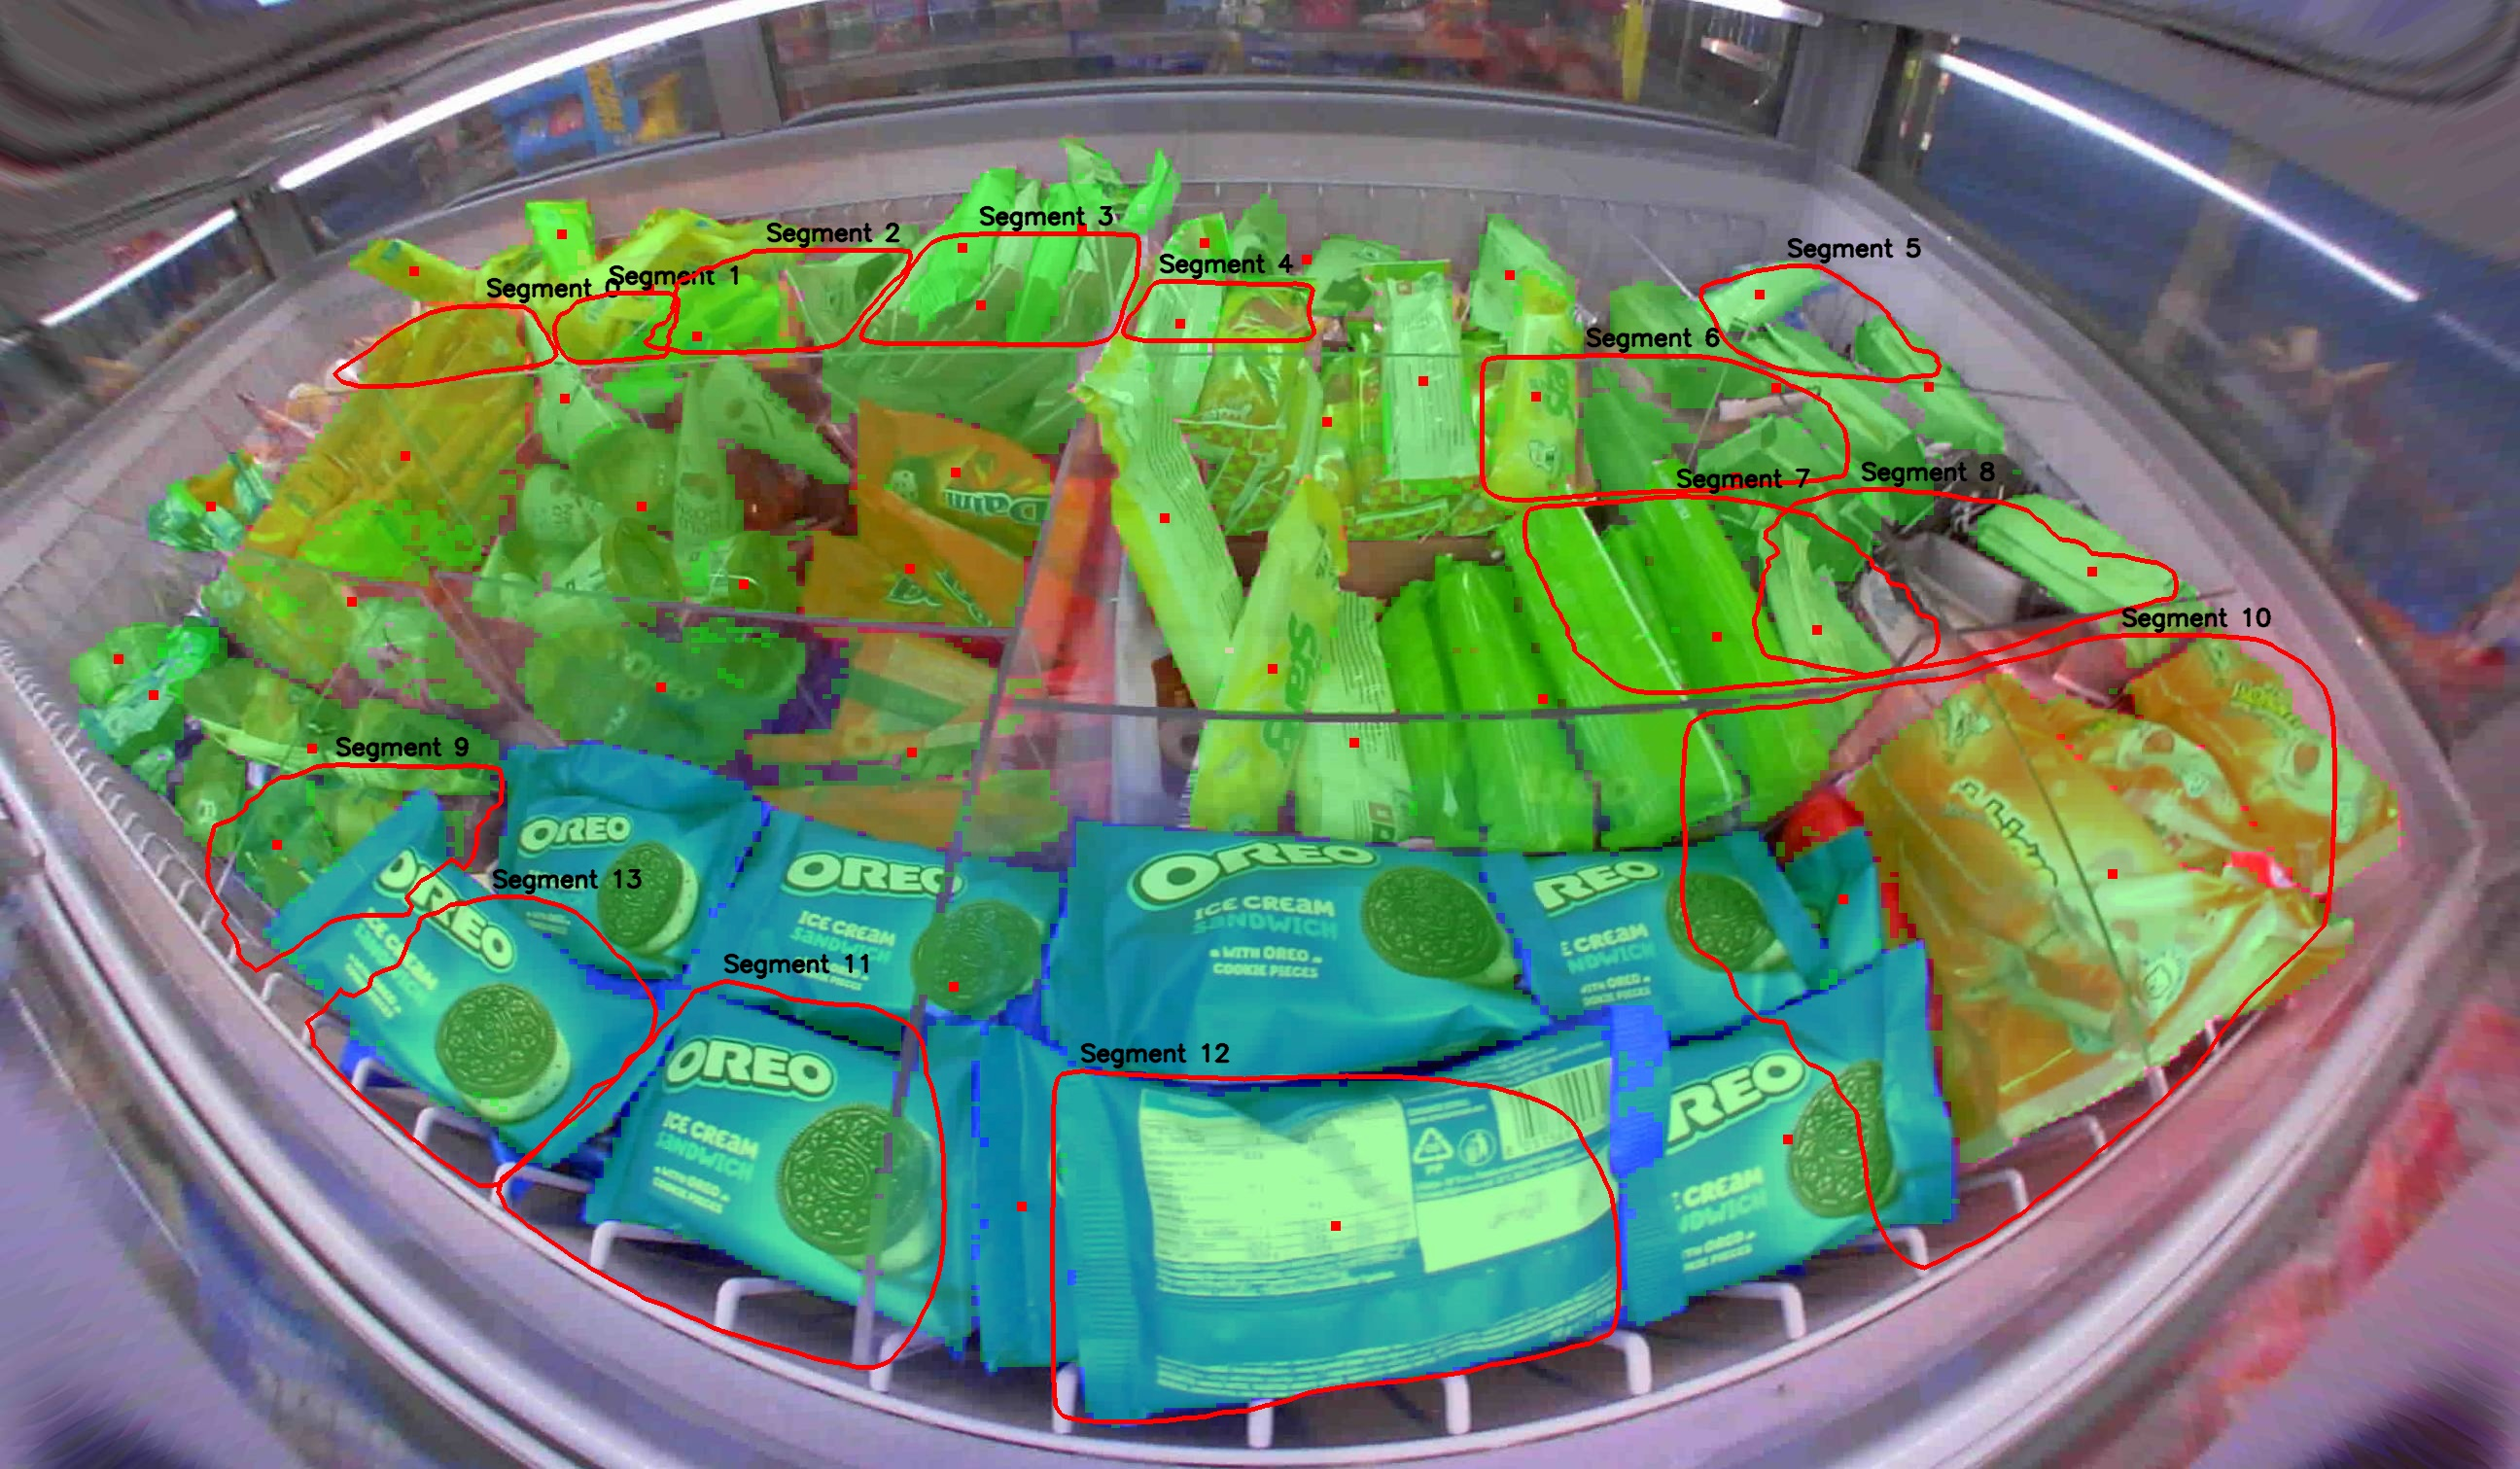

In [21]:
import cv2
from IPython.display import Image, display
import numpy as np

# 1. Initialize canvas
if "img_data" in globals() and img_data is not None:
    canvas = img_data.copy()
else:
    canvas = np.ones((1944, 2592, 3), dtype=np.uint8) * 255

# 2. Draw segments on canvas
segments_data = sorted_bucket_output[3]
for index, polygon in enumerate(segments_data):
    pts = np.array(polygon, dtype=np.int32)

    # Draw segment contour
    pts_reshaped = pts.reshape((-1, 1, 2))
    cv2.polylines(
        canvas, [pts_reshaped], isClosed=True, color=(0, 0, 255), thickness=3
    )

    # Draw label overlay
    label_text = f"Segment {index}"
    cv2.putText(
        canvas,
        label_text,
        (pts[0][0], pts[0][1] - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 0, 0),
        2,
        cv2.LINE_AA,
    )

# 3. Save full-resolution image
cv2.imwrite("test.jpg", canvas)

# 4. Display image only
display(Image(filename="test.jpg"))